🔍 Scanning the Test Dataset...
Found 992 images belonging to 15 classes.

📊 DATASET SUMMARY:
Total Test Images: 992
Total Crop Classes: 15

📂 EXACT CLASS MAPPING (Number -> Disease Name):
 [ 0] -> potato_bacteria
 [ 1] -> potato_early_blight
 [ 2] -> potato_fungi
 [ 3] -> potato_healthy
 [ 4] -> potato_late_blight
 [ 5] -> rice_blast
 [ 6] -> rice_brown_spot
 [ 7] -> rice_healthy
 [ 8] -> rice_sheath_blight
 [ 9] -> rice_tungro_virus
 [10] -> wheat_black_point
 [11] -> wheat_blast
 [12] -> wheat_fusarium_foot_rot
 [13] -> wheat_healthy
 [14] -> wheat_leaf_blight

🎨 Loading a visual sample of 4 test crops...


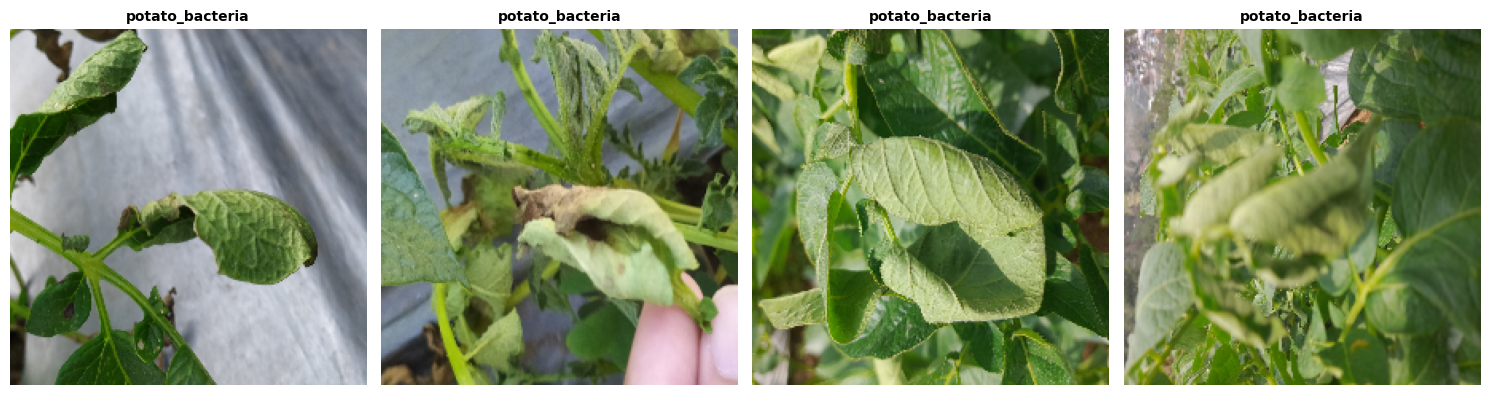


✅ Verification complete. Generator reset and ready for model testing.


In [1]:
# ==========================================
# CELL #1 - TEST DATASET VERIFICATION
# ==========================================
import os
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# The path to your test dataset
TEST_DIR = r"D:\MasterDataset\test"

print("🔍 Scanning the Test Dataset...")

# Load the data without shuffling (Critical for evaluation mapping)
test_datagen = ImageDataGenerator() 
test_gen = test_datagen.flow_from_directory(
    TEST_DIR, 
    target_size=(224, 224), 
    batch_size=8, 
    class_mode='categorical', 
    shuffle=False 
)

# ---------------------------------------------------------
# 1. PRINT DATASET SUMMARY
# ---------------------------------------------------------
class_dict = test_gen.class_indices
num_classes = len(class_dict)
total_images = test_gen.samples

print(f"\n📊 DATASET SUMMARY:")
print(f"Total Test Images: {total_images}")
print(f"Total Crop Classes: {num_classes}")

# ---------------------------------------------------------
# 2. PRINT EXACT CLASS MAPPING
# ---------------------------------------------------------
print("\n📂 EXACT CLASS MAPPING (Number -> Disease Name):")
# Reverse the dictionary to map Number -> Name
idx_to_class = {v: k for k, v in class_dict.items()}

for class_number in range(num_classes):
    print(f" [{class_number:2d}] -> {idx_to_class[class_number]}")

# ---------------------------------------------------------
# 3. VISUALIZE A SAMPLE BATCH
# ---------------------------------------------------------
print("\n🎨 Loading a visual sample of 4 test crops...")
imgs, labels = next(test_gen)

plt.figure(figsize=(15, 5))
for i in range(4):
    plt.subplot(1, 4, i + 1)
    
    # Convert pixels to uint8 for clean Matplotlib rendering
    img_display = imgs[i].astype('uint8')
    plt.imshow(img_display)
    
    # Extract the string name using our dictionary
    label_idx = np.argmax(labels[i])
    disease_name = idx_to_class[label_idx]
    
    plt.title(disease_name, fontsize=10, fontweight='bold')
    plt.axis('off')
    
plt.tight_layout()
plt.show()

# Reset the generator so it starts from the beginning for the actual model tests!
test_gen.reset()
print("\n✅ Verification complete. Generator reset and ready for model testing.")

🧹 Scrubbing GPU Memory for clean evaluation...
📁 Loading Unseen Test Data...
Found 992 images belonging to 15 classes.

🧠 Loading DenseNet121 Base Model from: D:\Final_Experiment\DenseNet121_Base.keras

📊 Running standard evaluation metric...
124/124 [==============================] - 47s 249ms/step - loss: 0.2839 - accuracy: 0.9093

🏆 DENSENET121 (PHASE 1) TEST ACCURACY: 90.93%

🔍 Generating detailed predictions for Matrix...
124/124 [==============================] - 22s 139ms/step

📄 --- THESIS DOCUMENTATION: DENSENET121 BASE ---
                         precision    recall  f1-score   support

        potato_bacteria       0.96      0.94      0.95        86
    potato_early_blight       0.97      0.97      0.97        76
           potato_fungi       0.92      0.91      0.91       106
         potato_healthy       0.93      0.95      0.94        98
     potato_late_blight       0.93      0.98      0.96        44
             rice_blast       0.84      0.78      0.81       125
     

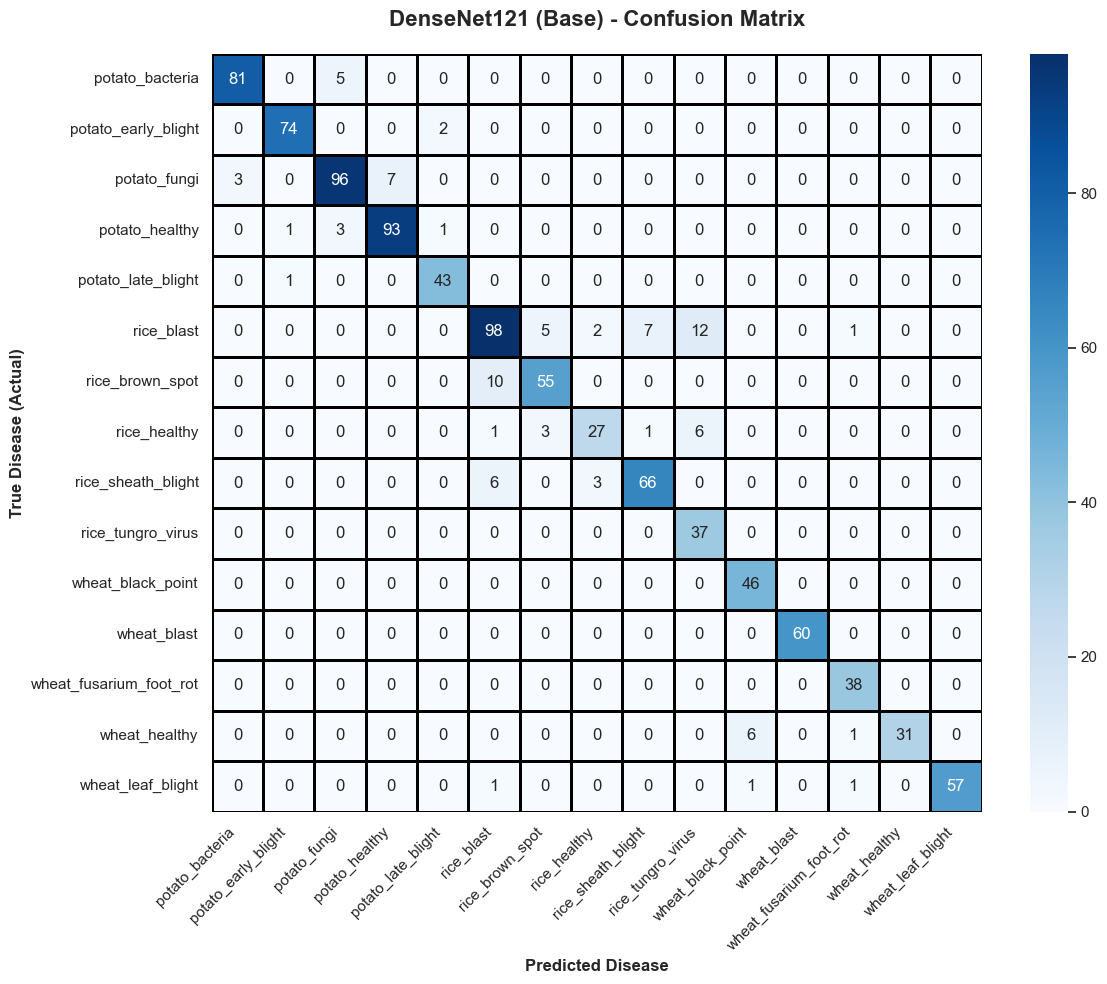

In [2]:
# ==========================================
# CELL #2 - EVALUATE DENSENET121 (PHASE 1 BASE)
# ==========================================
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import load_model
from sklearn.metrics import classification_report, confusion_matrix

print("🧹 Scrubbing GPU Memory for clean evaluation...")
tf.keras.backend.clear_session()

# Paths
FINAL_DIR = r"D:\Final_Experiment"
MODEL_PATH = os.path.join(FINAL_DIR, "DenseNet121_Base.keras")
TEST_DIR = r"D:\MasterDataset\test"

# ---------------------------------------------------------
# 1. LOAD TEST DATA (Raw Pixels - Model handles rescaling)
# ---------------------------------------------------------
print("📁 Loading Unseen Test Data...")
test_datagen = ImageDataGenerator() # No rescale here! 
test_gen = test_datagen.flow_from_directory(
    TEST_DIR, 
    target_size=(224, 224), 
    batch_size=8, 
    class_mode='categorical', 
    shuffle=False # CRITICAL: Must be False to match predictions with true labels
)

# ---------------------------------------------------------
# 2. LOAD MODEL & EVALUATE
# ---------------------------------------------------------
print(f"\n🧠 Loading DenseNet121 Base Model from: {MODEL_PATH}")
densenet_model = load_model(MODEL_PATH)

print("\n📊 Running standard evaluation metric...")
loss, accuracy = densenet_model.evaluate(test_gen, verbose=1)
print(f"\n🏆 DENSENET121 (PHASE 1) TEST ACCURACY: {accuracy * 100:.2f}%")

# ---------------------------------------------------------
# 3. GENERATE PREDICTIONS
# ---------------------------------------------------------
print("\n🔍 Generating detailed predictions for Matrix...")
test_gen.reset() # Reset generator before predict to ensure perfect alignment
predictions = densenet_model.predict(test_gen, verbose=1)

y_pred = np.argmax(predictions, axis=1)
y_true = test_gen.classes
class_names = list(test_gen.class_indices.keys())

# ---------------------------------------------------------
# 4. CLASSIFICATION REPORT
# ---------------------------------------------------------
print("\n📄 --- THESIS DOCUMENTATION: DENSENET121 BASE ---")
print(classification_report(y_true, y_pred, target_names=class_names))

# ---------------------------------------------------------
# 5. PLOT CONFUSION MATRIX
# ---------------------------------------------------------
print("\n🎨 Rendering DenseNet121 Confusion Matrix...")
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(12, 10))
sns.set_theme(style="whitegrid")

# Using 'Blues' to give DenseNet its own distinct visual identity in the thesis
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names,
            linewidths=1, linecolor='black')

plt.title('DenseNet121 (Base) - Confusion Matrix', fontsize=16, fontweight='bold', pad=20)
plt.ylabel('True Disease (Actual)', fontsize=12, fontweight='bold')
plt.xlabel('Predicted Disease', fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

cm_save_path = os.path.join(FINAL_DIR, "DenseNet121_Base_Confusion_Matrix.png")
plt.savefig(cm_save_path)
print(f"✅ Confusion Matrix safely saved to {cm_save_path}")
plt.show()

🧹 Scrubbing GPU Memory for clean evaluation...
📁 Loading Unseen Test Data...
Found 992 images belonging to 15 classes.

🧠 Loading MobileNetV2 Base Model from: D:\Final_Experiment\MobileNetV2_Base.keras

📊 Running standard evaluation metric...
124/124 [==============================] - 19s 128ms/step - loss: 0.2865 - accuracy: 0.8992

🏆 MOBILENETV2 (PHASE 1) TEST ACCURACY: 89.92%

🔍 Generating detailed predictions for Matrix...
124/124 [==============================] - 17s 129ms/step

📄 --- THESIS DOCUMENTATION: MOBILENETV2 BASE ---
                         precision    recall  f1-score   support

        potato_bacteria       0.92      0.98      0.95        86
    potato_early_blight       0.99      1.00      0.99        76
           potato_fungi       0.88      0.92      0.90       106
         potato_healthy       1.00      0.85      0.92        98
     potato_late_blight       0.94      1.00      0.97        44
             rice_blast       0.81      0.78      0.80       125
     

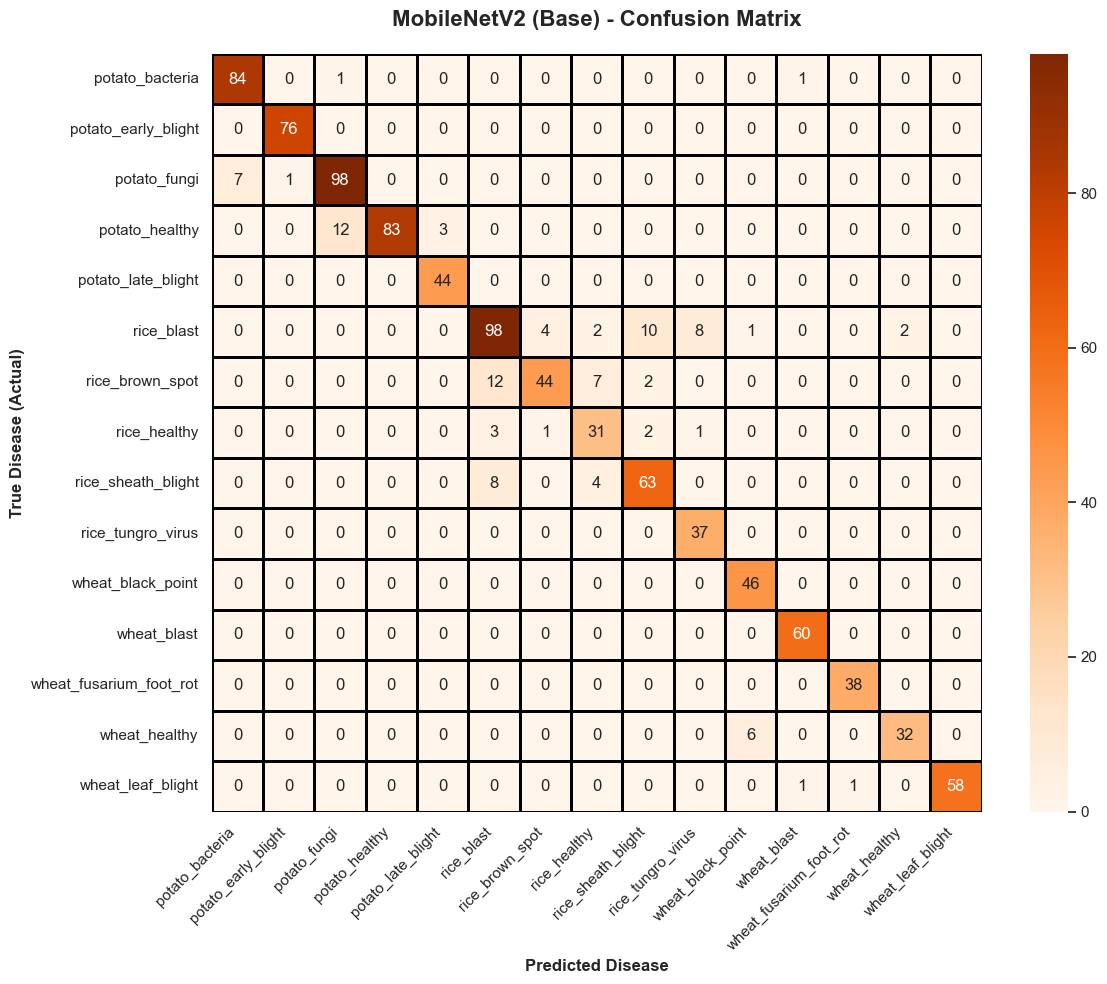

In [3]:
# ==========================================
# CELL #3 - EVALUATE MOBILENETV2 (PHASE 1 BASE)
# ==========================================
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import load_model
from sklearn.metrics import classification_report, confusion_matrix

print("🧹 Scrubbing GPU Memory for clean evaluation...")
tf.keras.backend.clear_session()

# Paths
FINAL_DIR = r"D:\Final_Experiment"
MODEL_PATH = os.path.join(FINAL_DIR, "MobileNetV2_Base.keras")
TEST_DIR = r"D:\MasterDataset\test"

# ---------------------------------------------------------
# 1. LOAD TEST DATA (Raw Pixels - Model handles rescaling)
# ---------------------------------------------------------
print("📁 Loading Unseen Test Data...")
test_datagen = ImageDataGenerator() # No rescale here! 
test_gen = test_datagen.flow_from_directory(
    TEST_DIR, 
    target_size=(224, 224), 
    batch_size=8, 
    class_mode='categorical', 
    shuffle=False # CRITICAL: Must be False to match predictions with true labels
)

# ---------------------------------------------------------
# 2. LOAD MODEL & EVALUATE
# ---------------------------------------------------------
print(f"\n🧠 Loading MobileNetV2 Base Model from: {MODEL_PATH}")
mobilenet_model = load_model(MODEL_PATH)

print("\n📊 Running standard evaluation metric...")
loss, accuracy = mobilenet_model.evaluate(test_gen, verbose=1)
print(f"\n🏆 MOBILENETV2 (PHASE 1) TEST ACCURACY: {accuracy * 100:.2f}%")

# ---------------------------------------------------------
# 3. GENERATE PREDICTIONS
# ---------------------------------------------------------
print("\n🔍 Generating detailed predictions for Matrix...")
test_gen.reset() # Reset generator before predict to ensure perfect alignment
predictions = mobilenet_model.predict(test_gen, verbose=1)

y_pred = np.argmax(predictions, axis=1)
y_true = test_gen.classes
class_names = list(test_gen.class_indices.keys())

# ---------------------------------------------------------
# 4. CLASSIFICATION REPORT
# ---------------------------------------------------------
print("\n📄 --- THESIS DOCUMENTATION: MOBILENETV2 BASE ---")
print(classification_report(y_true, y_pred, target_names=class_names))

# ---------------------------------------------------------
# 5. PLOT CONFUSION MATRIX
# ---------------------------------------------------------
print("\n🎨 Rendering MobileNetV2 Confusion Matrix...")
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(12, 10))
sns.set_theme(style="whitegrid")

# Using 'Oranges' to give MobileNet its own distinct visual identity in the thesis
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', 
            xticklabels=class_names, yticklabels=class_names,
            linewidths=1, linecolor='black')

plt.title('MobileNetV2 (Base) - Confusion Matrix', fontsize=16, fontweight='bold', pad=20)
plt.ylabel('True Disease (Actual)', fontsize=12, fontweight='bold')
plt.xlabel('Predicted Disease', fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

cm_save_path = os.path.join(FINAL_DIR, "MobileNetV2_Base_Confusion_Matrix.png")
plt.savefig(cm_save_path)
print(f"✅ Confusion Matrix safely saved to {cm_save_path}")
plt.show()

In [4]:
# ==========================================
# CELL #4 - EVALUATE EFFICIENTNETB0 (PHASE 1 BASE)
# ==========================================
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import Input, GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model
from sklearn.metrics import classification_report, confusion_matrix

print("🧹 Scrubbing GPU Memory for clean evaluation...")
tf.keras.backend.clear_session()

# Paths
FINAL_DIR = r"D:\Final_Experiment"
WEIGHTS_PATH = os.path.join(FINAL_DIR, "EfficientNetB0_Base_Weights.h5")
TEST_DIR = r"D:\MasterDataset\test"

# ---------------------------------------------------------
# 1. LOAD TEST DATA (Raw Pixels)
# ---------------------------------------------------------
print("📁 Loading Unseen Test Data...")
test_datagen = ImageDataGenerator() 
test_gen = test_datagen.flow_from_directory(
    TEST_DIR, 
    target_size=(224, 224), 
    batch_size=8, 
    class_mode='categorical', 
    shuffle=False # CRITICAL: Must be False
)

# ---------------------------------------------------------
# 2. REBUILD ARCHITECTURE & LOAD WEIGHTS
# ---------------------------------------------------------
print(f"\n🏗️ Rebuilding EfficientNet Architecture...")
inputs = Input(shape=(224, 224, 3), name="raw_image_input")
base_efficient = EfficientNetB0(weights=None, include_top=False, input_shape=(224, 224, 3))
x = base_efficient(inputs, training=False) 
x = GlobalAveragePooling2D(name="global_pooling")(x)
x = Dropout(0.3, name="head_dropout")(x) 
outputs = Dense(15, activation='softmax', name="final_predictions")(x)

efficient_model = Model(inputs=inputs, outputs=outputs)

print(f"📥 Injecting saved weights from: {WEIGHTS_PATH}")
efficient_model.load_weights(WEIGHTS_PATH)

# Must compile to use .evaluate()
efficient_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

print("\n📊 Running standard evaluation metric...")
loss, accuracy = efficient_model.evaluate(test_gen, verbose=1)
print(f"\n🏆 EFFICIENTNETB0 (PHASE 1) TEST ACCURACY: {accuracy * 100:.2f}%")

# ---------------------------------------------------------
# 3. GENERATE PREDICTIONS
# ---------------------------------------------------------
print("\n🔍 Generating detailed predictions for Matrix...")
test_gen.reset() 
predictions = efficient_model.predict(test_gen, verbose=1)

y_pred = np.argmax(predictions, axis=1)
y_true = test_gen.classes
class_names = list(test_gen.class_indices.keys())

# ---------------------------------------------------------
# 4. CLASSIFICATION REPORT
# ---------------------------------------------------------
print("\n📄 --- THESIS DOCUMENTATION: EFFICIENTNETB0 BASE ---")
print(classification_report(y_true, y_pred, target_names=class_names))

# ---------------------------------------------------------
# 5. PLOT CONFUSION MATRIX
# ---------------------------------------------------------
print("\n🎨 Rendering EfficientNetB0 Confusion Matrix...")
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(12, 10))
sns.set_theme(style="whitegrid")

# Using 'Purples' to give EfficientNet its own distinct visual identity
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', 
            xticklabels=class_names, yticklabels=class_names,
            linewidths=1, linecolor='black')

plt.title('EfficientNetB0 (Base) - Confusion Matrix', fontsize=16, fontweight='bold', pad=20)
plt.ylabel('True Disease (Actual)', fontsize=12, fontweight='bold')
plt.xlabel('Predicted Disease', fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

cm_save_path = os.path.join(FINAL_DIR, "EfficientNetB0_Base_Confusion_Matrix.png")
plt.savefig(cm_save_path)
print(f"✅ Confusion Matrix safely saved to {cm_save_path}")
plt.show()

🧹 Scrubbing GPU Memory for clean evaluation...
📁 Loading Unseen Test Data...
Found 992 images belonging to 15 classes.

🏗️ Rebuilding EfficientNet Architecture...
📥 Injecting saved weights from: D:\Final_Experiment\EfficientNetB0_Base_Weights.h5


ValueError: axes don't match array

🧹 Scrubbing GPU Memory for clean evaluation...
📁 Loading Unseen Test Data...
Found 992 images belonging to 15 classes.

🏗️ Rebuilding EfficientNet Architecture exactly as trained...
📥 Injecting saved weights from: D:\Final_Experiment\EfficientNetB0_Base_Weights.h5

📊 Running standard evaluation metric...
124/124 [==============================] - 24s 147ms/step - loss: 0.2188 - accuracy: 0.9244

🏆 EFFICIENTNETB0 (PHASE 1) TEST ACCURACY: 92.44%

🔍 Generating detailed predictions for Matrix...
124/124 [==============================] - 20s 140ms/step

📄 --- THESIS DOCUMENTATION: EFFICIENTNETB0 BASE ---
                         precision    recall  f1-score   support

        potato_bacteria       0.98      0.93      0.95        86
    potato_early_blight       1.00      0.97      0.99        76
           potato_fungi       0.91      0.97      0.94       106
         potato_healthy       0.98      0.91      0.94        98
     potato_late_blight       0.88      1.00      0.94        44
 

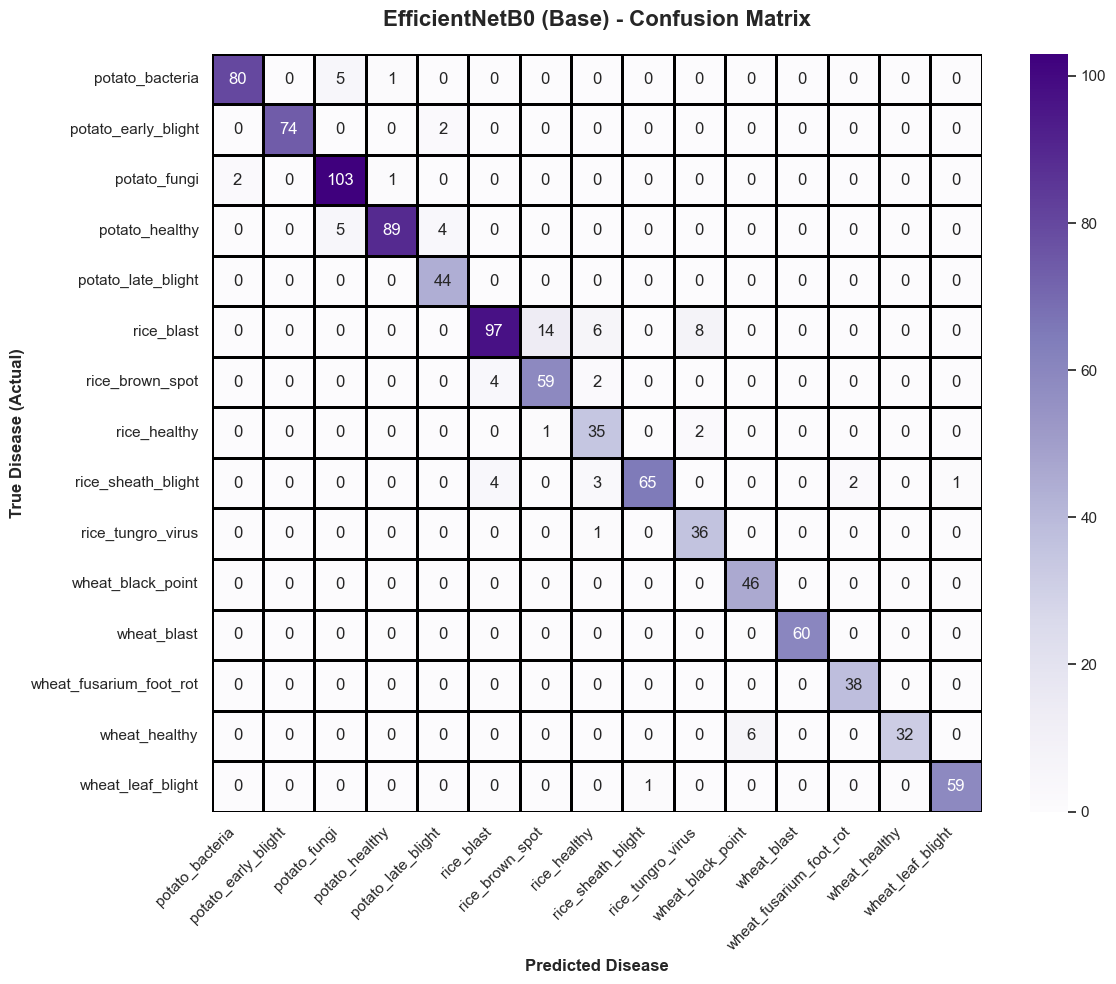

In [6]:
# ==========================================
# CELL #4 - EVALUATE EFFICIENTNETB0 (PHASE 1 BASE)
# ==========================================
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import Input, GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model
from sklearn.metrics import classification_report, confusion_matrix

print("🧹 Scrubbing GPU Memory for clean evaluation...")
tf.keras.backend.clear_session()

# Paths
FINAL_DIR = r"D:\Final_Experiment"
WEIGHTS_PATH = os.path.join(FINAL_DIR, "EfficientNetB0_Base_Weights.h5")
TEST_DIR = r"D:\MasterDataset\test"

# ---------------------------------------------------------
# 1. LOAD TEST DATA
# ---------------------------------------------------------
print("📁 Loading Unseen Test Data...")
test_datagen = ImageDataGenerator() 
test_gen = test_datagen.flow_from_directory(
    TEST_DIR, 
    target_size=(224, 224), 
    batch_size=8, 
    class_mode='categorical', 
    shuffle=False
)

# ---------------------------------------------------------
# 2. REBUILD ARCHITECTURE & LOAD WEIGHTS
# ---------------------------------------------------------
print(f"\n🏗️ Rebuilding EfficientNet Architecture exactly as trained...")
inputs = Input(shape=(224, 224, 3), name="raw_image_input")
base_efficient = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# 🚨 THE FIX: This line MUST exist so the weight lists align perfectly!
base_efficient.trainable = False 

x = base_efficient(inputs, training=False) 
x = GlobalAveragePooling2D(name="global_pooling")(x)
x = Dropout(0.3, name="head_dropout")(x) 
outputs = Dense(15, activation='softmax', name="final_predictions")(x)

efficient_model = Model(inputs=inputs, outputs=outputs, name="EfficientNet_Phase1_Base")

print(f"📥 Injecting saved weights from: {WEIGHTS_PATH}")
# Now it will slot in perfectly.
efficient_model.load_weights(WEIGHTS_PATH)

# Must compile to use .evaluate()
efficient_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

print("\n📊 Running standard evaluation metric...")
loss, accuracy = efficient_model.evaluate(test_gen, verbose=1)
print(f"\n🏆 EFFICIENTNETB0 (PHASE 1) TEST ACCURACY: {accuracy * 100:.2f}%")

# ---------------------------------------------------------
# 3. GENERATE PREDICTIONS
# ---------------------------------------------------------
print("\n🔍 Generating detailed predictions for Matrix...")
test_gen.reset() 
predictions = efficient_model.predict(test_gen, verbose=1)

y_pred = np.argmax(predictions, axis=1)
y_true = test_gen.classes
class_names = list(test_gen.class_indices.keys())

# ---------------------------------------------------------
# 4. CLASSIFICATION REPORT
# ---------------------------------------------------------
print("\n📄 --- THESIS DOCUMENTATION: EFFICIENTNETB0 BASE ---")
print(classification_report(y_true, y_pred, target_names=class_names))

# ---------------------------------------------------------
# 5. PLOT CONFUSION MATRIX
# ---------------------------------------------------------
print("\n🎨 Rendering EfficientNetB0 Confusion Matrix...")
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(12, 10))
sns.set_theme(style="whitegrid")

sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', 
            xticklabels=class_names, yticklabels=class_names,
            linewidths=1, linecolor='black')

plt.title('EfficientNetB0 (Base) - Confusion Matrix', fontsize=16, fontweight='bold', pad=20)
plt.ylabel('True Disease (Actual)', fontsize=12, fontweight='bold')
plt.xlabel('Predicted Disease', fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

cm_save_path = os.path.join(FINAL_DIR, "EfficientNetB0_Base_Confusion_Matrix.png")
plt.savefig(cm_save_path)
print(f"✅ Confusion Matrix safely saved to {cm_save_path}")
plt.show()

📊 Generating Thesis-Ready Comparison Chart...
✅ High-resolution comparison chart saved to: D:\Final_Experiment\Phase1_Base_Models_Comparison.png


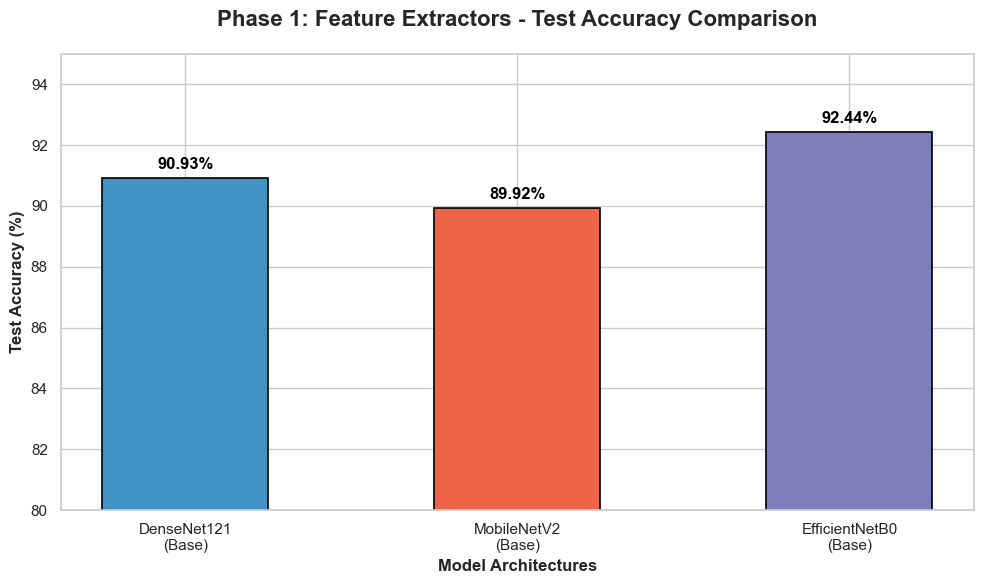

In [7]:
# ==========================================
# CELL #5 - BASE MODELS PERFORMANCE COMPARISON
# ==========================================
import os
import matplotlib.pyplot as plt
import seaborn as sns

print("📊 Generating Thesis-Ready Comparison Chart...")

# 1. Define the Final Test Accuracies
models = ['DenseNet121\n(Base)', 'MobileNetV2\n(Base)', 'EfficientNetB0\n(Base)']
accuracies = [90.93, 89.92, 92.44]

# 2. Match the Confusion Matrix Colors (Blue, Orange, Purple)
colors = ['#4292c6', '#ef6548', '#807dba']

# 3. Setup the Plot Canvas
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

# 4. Create the Bar Chart
bars = plt.bar(models, accuracies, color=colors, width=0.5, edgecolor='black', linewidth=1.2)

# 5. Add Exact Percentage Labels on Top of Each Bar
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.2, f"{yval}%", 
             ha='center', va='bottom', fontsize=12, fontweight='bold', color='black')

# 6. Formatting for Academic Presentation
plt.ylim(80, 95)  # Set Y-axis to highlight the variance between models
plt.title('Phase 1: Feature Extractors - Test Accuracy Comparison', fontsize=16, fontweight='bold', pad=20)
plt.ylabel('Test Accuracy (%)', fontsize=12, fontweight='bold')
plt.xlabel('Model Architectures', fontsize=12, fontweight='bold')

plt.tight_layout()

# 7. Save High-Resolution Image
FINAL_DIR = r"D:\Final_Experiment"
save_path = os.path.join(FINAL_DIR, "Phase1_Base_Models_Comparison.png")
plt.savefig(save_path, dpi=300) # dpi=300 ensures it stays sharp when printed on paper

print(f"✅ High-resolution comparison chart saved to: {save_path}")
plt.show()

🧹 Scrubbing GPU Memory for clean evaluation...
📁 Loading Unseen Test Data...
Found 992 images belonging to 15 classes.

🧠 Loading DenseNet121 FINE-TUNED Model from: D:\Final_Experiment\DenseNet121_FineTuned.keras

📊 Running standard evaluation metric...
124/124 [==============================] - 26s 140ms/step - loss: 0.2235 - accuracy: 0.9254

🏆 DENSENET121 (PHASE 2 FINE-TUNED) TEST ACCURACY: 92.54%

🔍 Generating detailed predictions for Matrix...
124/124 [==============================] - 23s 149ms/step

📄 --- THESIS DOCUMENTATION: DENSENET121 FINE-TUNED ---
                         precision    recall  f1-score   support

        potato_bacteria       0.96      0.93      0.95        86
    potato_early_blight       0.99      0.97      0.98        76
           potato_fungi       0.93      0.94      0.93       106
         potato_healthy       0.97      0.95      0.96        98
     potato_late_blight       0.90      0.98      0.93        44
             rice_blast       0.87      0.

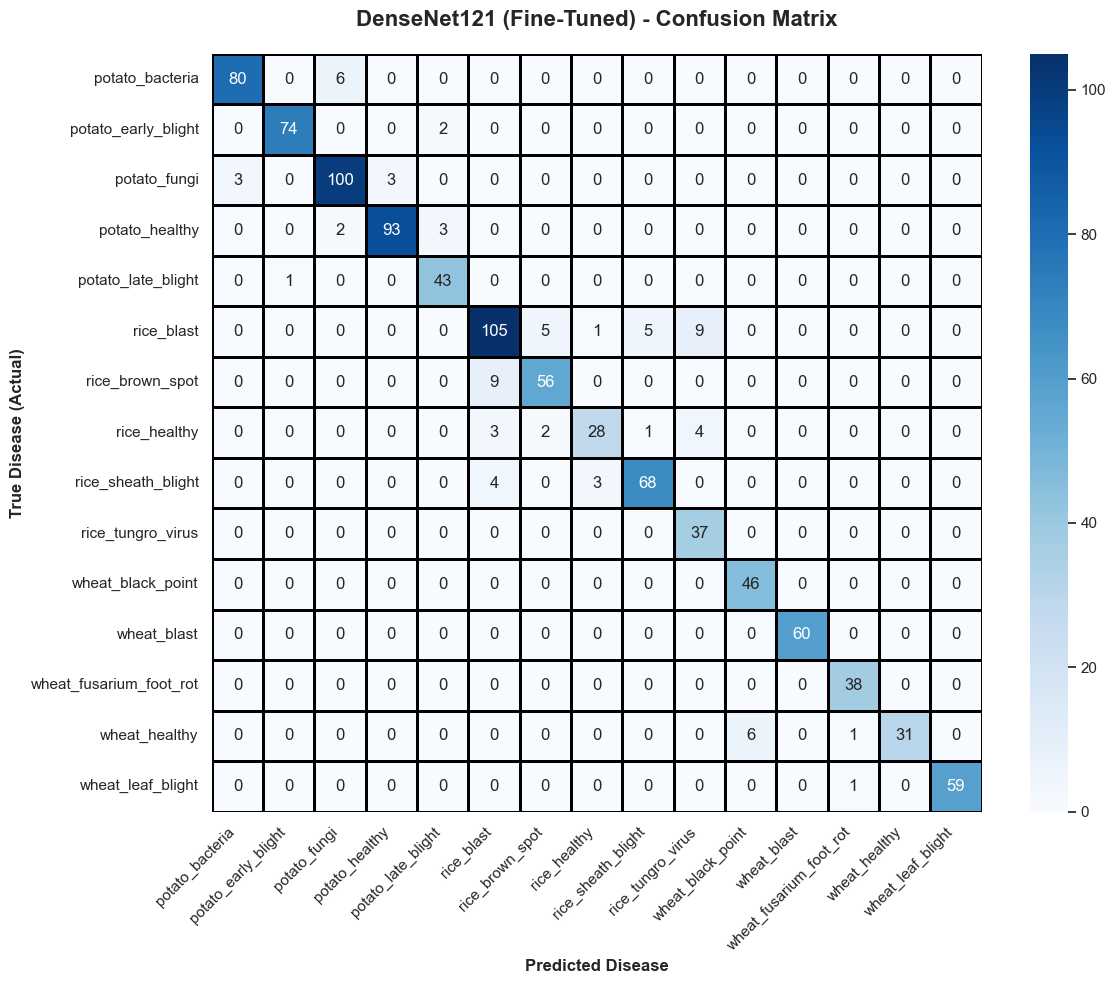

In [8]:
# ==========================================
# CELL #6 - EVALUATE DENSENET121 (PHASE 2 FINE-TUNED)
# ==========================================
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import load_model
from sklearn.metrics import classification_report, confusion_matrix

print("🧹 Scrubbing GPU Memory for clean evaluation...")
tf.keras.backend.clear_session()

# Paths
FINAL_DIR = r"D:\Final_Experiment"
MODEL_PATH = os.path.join(FINAL_DIR, "DenseNet121_FineTuned.keras")
TEST_DIR = r"D:\MasterDataset\test"

# ---------------------------------------------------------
# 1. LOAD TEST DATA (Raw Pixels - Model handles rescaling)
# ---------------------------------------------------------
print("📁 Loading Unseen Test Data...")
test_datagen = ImageDataGenerator() 
test_gen = test_datagen.flow_from_directory(
    TEST_DIR, 
    target_size=(224, 224), 
    batch_size=8, 
    class_mode='categorical', 
    shuffle=False # CRITICAL: Must be False
)

# ---------------------------------------------------------
# 2. LOAD MODEL & EVALUATE
# ---------------------------------------------------------
print(f"\n🧠 Loading DenseNet121 FINE-TUNED Model from: {MODEL_PATH}")
densenet_ft_model = load_model(MODEL_PATH)

print("\n📊 Running standard evaluation metric...")
loss, accuracy = densenet_ft_model.evaluate(test_gen, verbose=1)
print(f"\n🏆 DENSENET121 (PHASE 2 FINE-TUNED) TEST ACCURACY: {accuracy * 100:.2f}%")

# ---------------------------------------------------------
# 3. GENERATE PREDICTIONS
# ---------------------------------------------------------
print("\n🔍 Generating detailed predictions for Matrix...")
test_gen.reset() 
predictions = densenet_ft_model.predict(test_gen, verbose=1)

y_pred = np.argmax(predictions, axis=1)
y_true = test_gen.classes
class_names = list(test_gen.class_indices.keys())

# ---------------------------------------------------------
# 4. CLASSIFICATION REPORT
# ---------------------------------------------------------
print("\n📄 --- THESIS DOCUMENTATION: DENSENET121 FINE-TUNED ---")
print(classification_report(y_true, y_pred, target_names=class_names))

# ---------------------------------------------------------
# 5. PLOT CONFUSION MATRIX
# ---------------------------------------------------------
print("\n🎨 Rendering DenseNet121 Fine-Tuned Confusion Matrix...")
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(12, 10))
sns.set_theme(style="whitegrid")

# Sticking with 'Blues' for DenseNet's identity
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names,
            linewidths=1, linecolor='black')

plt.title('DenseNet121 (Fine-Tuned) - Confusion Matrix', fontsize=16, fontweight='bold', pad=20)
plt.ylabel('True Disease (Actual)', fontsize=12, fontweight='bold')
plt.xlabel('Predicted Disease', fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

cm_save_path = os.path.join(FINAL_DIR, "DenseNet121_FineTuned_Confusion_Matrix.png")
plt.savefig(cm_save_path)
print(f"✅ Confusion Matrix safely saved to {cm_save_path}")
plt.show()

🧹 Scrubbing GPU Memory for clean evaluation...
📁 Loading Unseen Test Data...
Found 992 images belonging to 15 classes.

🧠 Loading MobileNetV2 FINE-TUNED Model from: D:\Final_Experiment\MobileNetV2_FineTuned.keras

📊 Running standard evaluation metric...
124/124 [==============================] - 21s 147ms/step - loss: 0.1749 - accuracy: 0.9365

🏆 MOBILENETV2 (PHASE 2 FINE-TUNED) TEST ACCURACY: 93.65%

🔍 Generating detailed predictions for Matrix...
124/124 [==============================] - 18s 135ms/step

📄 --- THESIS DOCUMENTATION: MOBILENETV2 FINE-TUNED ---
                         precision    recall  f1-score   support

        potato_bacteria       0.93      0.98      0.95        86
    potato_early_blight       1.00      1.00      1.00        76
           potato_fungi       0.92      0.94      0.93       106
         potato_healthy       1.00      0.91      0.95        98
     potato_late_blight       0.96      1.00      0.98        44
             rice_blast       0.91      0.

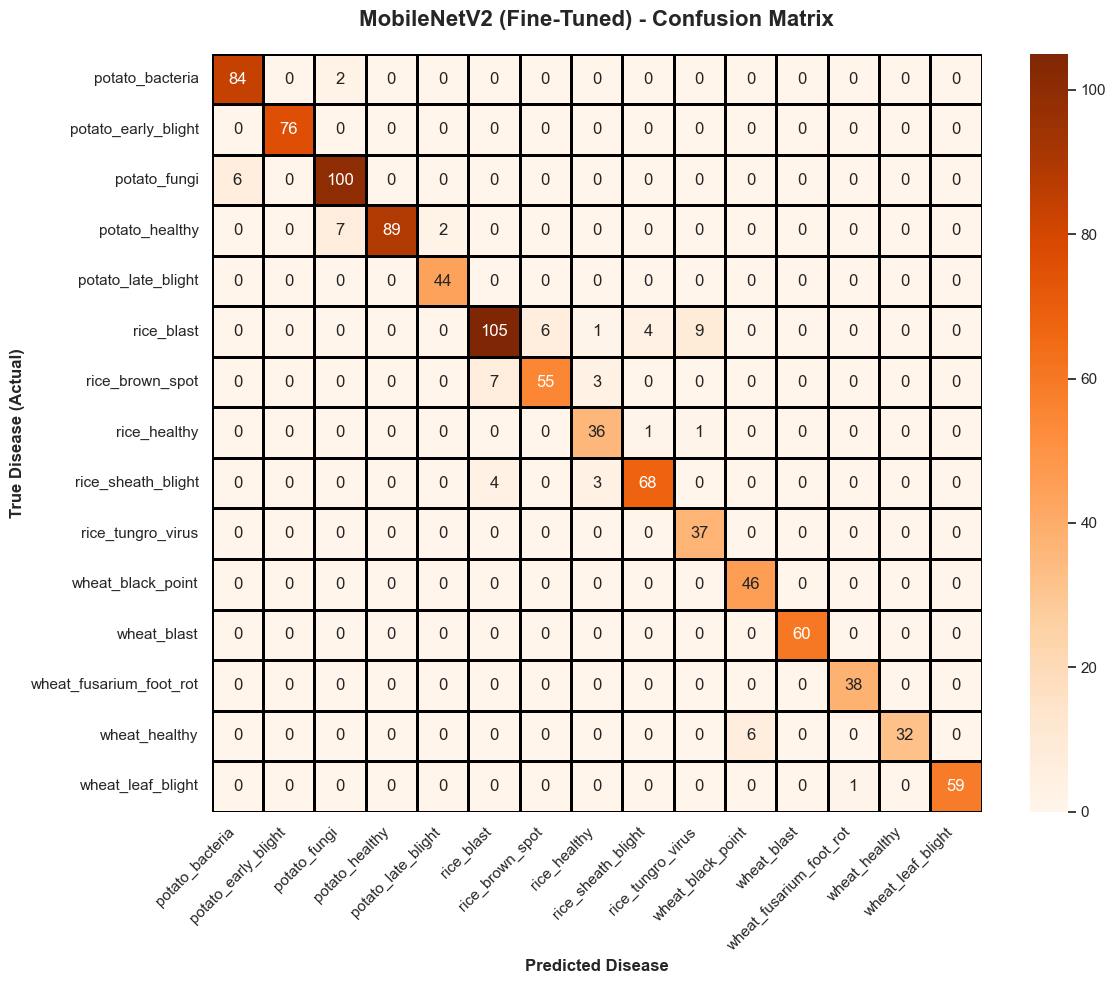

In [9]:
# ==========================================
# CELL #7 - EVALUATE MOBILENETV2 (PHASE 2 FINE-TUNED)
# ==========================================
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import load_model
from sklearn.metrics import classification_report, confusion_matrix

print("🧹 Scrubbing GPU Memory for clean evaluation...")
tf.keras.backend.clear_session()

# Paths
FINAL_DIR = r"D:\Final_Experiment"
MODEL_PATH = os.path.join(FINAL_DIR, "MobileNetV2_FineTuned.keras")
TEST_DIR = r"D:\MasterDataset\test"

# ---------------------------------------------------------
# 1. LOAD TEST DATA (Raw Pixels - Model handles rescaling)
# ---------------------------------------------------------
print("📁 Loading Unseen Test Data...")
test_datagen = ImageDataGenerator() 
test_gen = test_datagen.flow_from_directory(
    TEST_DIR, 
    target_size=(224, 224), 
    batch_size=8, 
    class_mode='categorical', 
    shuffle=False # CRITICAL: Must be False
)

# ---------------------------------------------------------
# 2. LOAD MODEL & EVALUATE
# ---------------------------------------------------------
print(f"\n🧠 Loading MobileNetV2 FINE-TUNED Model from: {MODEL_PATH}")
mobile_ft_model = load_model(MODEL_PATH)

print("\n📊 Running standard evaluation metric...")
loss, accuracy = mobile_ft_model.evaluate(test_gen, verbose=1)
print(f"\n🏆 MOBILENETV2 (PHASE 2 FINE-TUNED) TEST ACCURACY: {accuracy * 100:.2f}%")

# ---------------------------------------------------------
# 3. GENERATE PREDICTIONS
# ---------------------------------------------------------
print("\n🔍 Generating detailed predictions for Matrix...")
test_gen.reset() 
predictions = mobile_ft_model.predict(test_gen, verbose=1)

y_pred = np.argmax(predictions, axis=1)
y_true = test_gen.classes
class_names = list(test_gen.class_indices.keys())

# ---------------------------------------------------------
# 4. CLASSIFICATION REPORT
# ---------------------------------------------------------
print("\n📄 --- THESIS DOCUMENTATION: MOBILENETV2 FINE-TUNED ---")
print(classification_report(y_true, y_pred, target_names=class_names))

# ---------------------------------------------------------
# 5. PLOT CONFUSION MATRIX
# ---------------------------------------------------------
print("\n🎨 Rendering MobileNetV2 Fine-Tuned Confusion Matrix...")
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(12, 10))
sns.set_theme(style="whitegrid")

# Sticking with 'Oranges' for MobileNet's identity
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', 
            xticklabels=class_names, yticklabels=class_names,
            linewidths=1, linecolor='black')

plt.title('MobileNetV2 (Fine-Tuned) - Confusion Matrix', fontsize=16, fontweight='bold', pad=20)
plt.ylabel('True Disease (Actual)', fontsize=12, fontweight='bold')
plt.xlabel('Predicted Disease', fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

cm_save_path = os.path.join(FINAL_DIR, "MobileNetV2_FineTuned_Confusion_Matrix.png")
plt.savefig(cm_save_path)
print(f"✅ Confusion Matrix safely saved to {cm_save_path}")
plt.show()

🧹 Scrubbing GPU Memory for clean evaluation...
📁 Loading Unseen Test Data...
Found 992 images belonging to 15 classes.

🏗️ Rebuilding EfficientNet Master Architecture...
📥 Injecting saved Phase 2 weights from: D:\Final_Experiment\EfficientNetB0_Final_Weights.h5

📊 Running standard evaluation metric...
124/124 [==============================] - 26s 142ms/step - loss: 0.1878 - accuracy: 0.9315

🏆 EFFICIENTNETB0 (PHASE 2 FINE-TUNED) TEST ACCURACY: 93.15%

🔍 Generating detailed predictions for Matrix...
124/124 [==============================] - 21s 150ms/step

📄 --- THESIS DOCUMENTATION: EFFICIENTNETB0 FINE-TUNED ---
                         precision    recall  f1-score   support

        potato_bacteria       0.95      0.98      0.97        86
    potato_early_blight       1.00      0.96      0.98        76
           potato_fungi       0.94      0.96      0.95       106
         potato_healthy       1.00      0.92      0.96        98
     potato_late_blight       0.86      1.00      0.

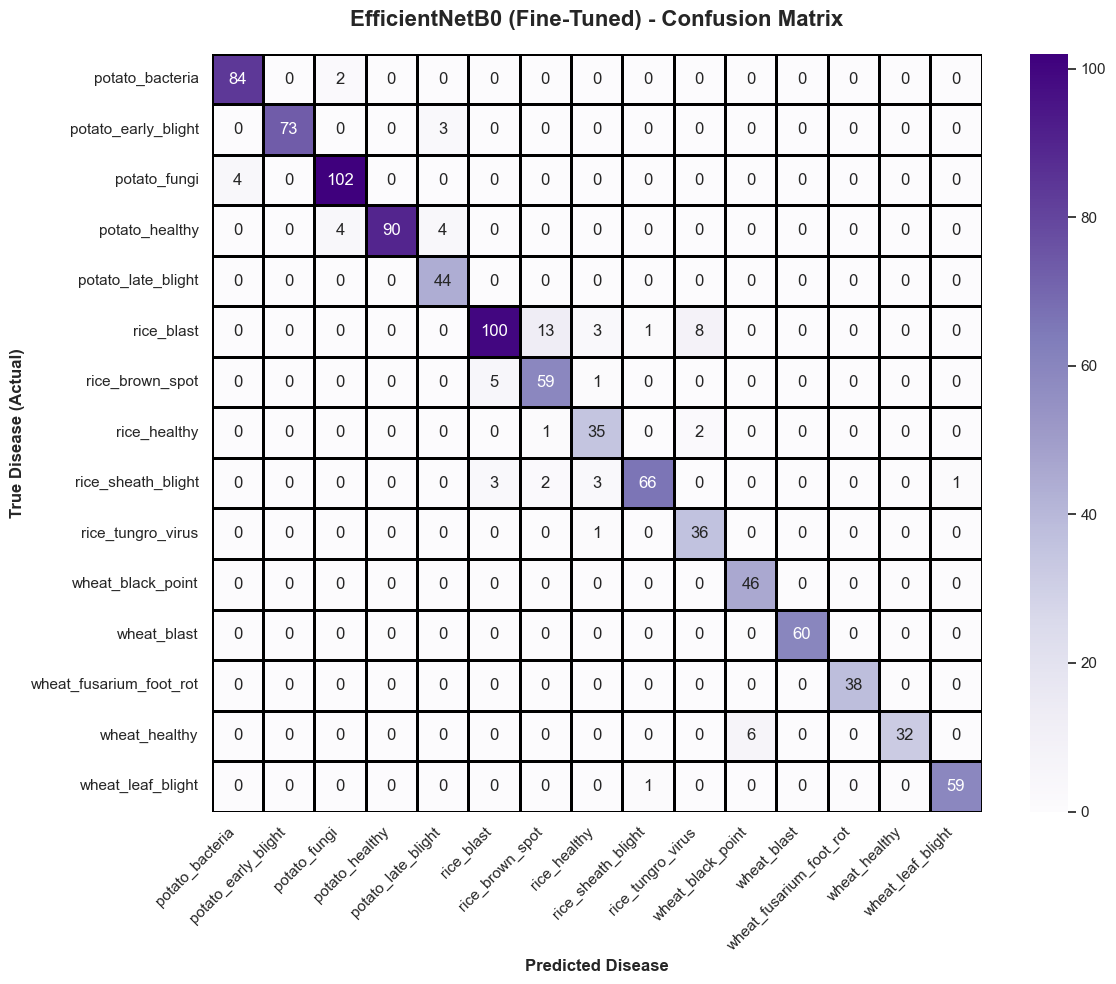

In [10]:
# ==========================================
# CELL #8 - EVALUATE EFFICIENTNETB0 (PHASE 2 FINE-TUNED)
# ==========================================
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import Input, GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model
from sklearn.metrics import classification_report, confusion_matrix

print("🧹 Scrubbing GPU Memory for clean evaluation...")
tf.keras.backend.clear_session()

# Paths
FINAL_DIR = r"D:\Final_Experiment"
WEIGHTS_PATH = os.path.join(FINAL_DIR, "EfficientNetB0_Final_Weights.h5")
TEST_DIR = r"D:\MasterDataset\test"

# ---------------------------------------------------------
# 1. LOAD TEST DATA (Raw Pixels)
# ---------------------------------------------------------
print("📁 Loading Unseen Test Data...")
test_datagen = ImageDataGenerator() 
test_gen = test_datagen.flow_from_directory(
    TEST_DIR, 
    target_size=(224, 224), 
    batch_size=8, 
    class_mode='categorical', 
    shuffle=False # CRITICAL: Must be False
)

# ---------------------------------------------------------
# 2. REBUILD EXACT PHASE 2 ARCHITECTURE
# ---------------------------------------------------------
print(f"\n🏗️ Rebuilding EfficientNet Master Architecture...")
inputs = Input(shape=(224, 224, 3), name="raw_image_input")
base_efficient = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# 🚨 THE FIX: We MUST replicate the exact trainable state from Phase 2 
# before loading the weights, otherwise the arrays will clash!
base_efficient.trainable = True 
for layer in base_efficient.layers[:-50]:
    layer.trainable = False

x = base_efficient(inputs, training=False) 
x = GlobalAveragePooling2D(name="global_pooling")(x)
x = Dropout(0.3, name="head_dropout")(x) 
outputs = Dense(15, activation='softmax', name="final_predictions")(x)

efficient_ft_model = Model(inputs=inputs, outputs=outputs, name="EfficientNet_Master")

# ---------------------------------------------------------
# 3. INJECT WEIGHTS & COMPILE
# ---------------------------------------------------------
print(f"📥 Injecting saved Phase 2 weights from: {WEIGHTS_PATH}")
efficient_ft_model.load_weights(WEIGHTS_PATH)

# Must compile to use .evaluate()
efficient_ft_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

print("\n📊 Running standard evaluation metric...")
loss, accuracy = efficient_ft_model.evaluate(test_gen, verbose=1)
print(f"\n🏆 EFFICIENTNETB0 (PHASE 2 FINE-TUNED) TEST ACCURACY: {accuracy * 100:.2f}%")

# ---------------------------------------------------------
# 4. GENERATE PREDICTIONS
# ---------------------------------------------------------
print("\n🔍 Generating detailed predictions for Matrix...")
test_gen.reset() 
predictions = efficient_ft_model.predict(test_gen, verbose=1)

y_pred = np.argmax(predictions, axis=1)
y_true = test_gen.classes
class_names = list(test_gen.class_indices.keys())

# ---------------------------------------------------------
# 5. CLASSIFICATION REPORT
# ---------------------------------------------------------
print("\n📄 --- THESIS DOCUMENTATION: EFFICIENTNETB0 FINE-TUNED ---")
print(classification_report(y_true, y_pred, target_names=class_names))

# ---------------------------------------------------------
# 6. PLOT CONFUSION MATRIX
# ---------------------------------------------------------
print("\n🎨 Rendering EfficientNetB0 Fine-Tuned Confusion Matrix...")
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(12, 10))
sns.set_theme(style="whitegrid")

# Purples for EfficientNet
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', 
            xticklabels=class_names, yticklabels=class_names,
            linewidths=1, linecolor='black')

plt.title('EfficientNetB0 (Fine-Tuned) - Confusion Matrix', fontsize=16, fontweight='bold', pad=20)
plt.ylabel('True Disease (Actual)', fontsize=12, fontweight='bold')
plt.xlabel('Predicted Disease', fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

cm_save_path = os.path.join(FINAL_DIR, "EfficientNetB0_FineTuned_Confusion_Matrix.png")
plt.savefig(cm_save_path)
print(f"✅ Confusion Matrix safely saved to {cm_save_path}")
plt.show()

📊 Generating Thesis-Ready Phase 2 Comparison Chart...
✅ High-resolution Phase 2 chart saved to: D:\Final_Experiment\Phase2_FineTuned_Comparison.png


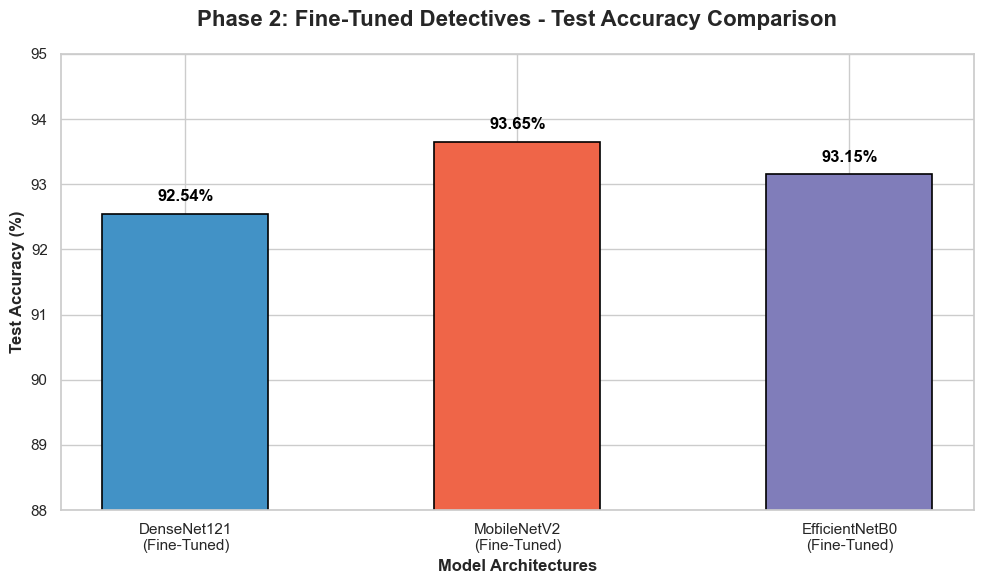

In [11]:
# ==========================================
# CELL #9 - FINE-TUNED MODELS PERFORMANCE COMPARISON
# ==========================================
import os
import matplotlib.pyplot as plt
import seaborn as sns

print("📊 Generating Thesis-Ready Phase 2 Comparison Chart...")

# 1. Define the Fine-Tuned Test Accuracies
models = ['DenseNet121\n(Fine-Tuned)', 'MobileNetV2\n(Fine-Tuned)', 'EfficientNetB0\n(Fine-Tuned)']
accuracies = [92.54, 93.65, 93.15]

# 2. Match the established thesis color scheme (Blue, Orange, Purple)
colors = ['#4292c6', '#ef6548', '#807dba']

# 3. Setup the Plot Canvas
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

# 4. Create the Bar Chart
bars = plt.bar(models, accuracies, color=colors, width=0.5, edgecolor='black', linewidth=1.2)

# 5. Add Exact Percentage Labels on Top of Each Bar
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.15, f"{yval}%", 
             ha='center', va='bottom', fontsize=12, fontweight='bold', color='black')

# 6. Formatting for Academic Presentation
plt.ylim(88, 95)  # Zoomed in to clearly highlight the new rankings
plt.title('Phase 2: Fine-Tuned Detectives - Test Accuracy Comparison', fontsize=16, fontweight='bold', pad=20)
plt.ylabel('Test Accuracy (%)', fontsize=12, fontweight='bold')
plt.xlabel('Model Architectures', fontsize=12, fontweight='bold')

plt.tight_layout()

# 7. Save High-Resolution Image
FINAL_DIR = r"D:\Final_Experiment"
save_path = os.path.join(FINAL_DIR, "Phase2_FineTuned_Comparison.png")
plt.savefig(save_path, dpi=300)

print(f"✅ High-resolution Phase 2 chart saved to: {save_path}")
plt.show()

🧹 Scrubbing GPU Memory for clean evaluation...
📁 Loading Unseen Test Data...
Found 992 images belonging to 15 classes.

🧠 Loading Master Fusion Boss Model from: D:\Final_Experiment\Final_Fusion_Boss.keras

📊 Running standard evaluation metric...
124/124 [==============================] - 42s 165ms/step - loss: 0.2806 - accuracy: 0.9123

🏆 MASTER FUSION BOSS TEST ACCURACY: 91.23%

🔍 Generating detailed predictions for Matrix...
124/124 [==============================] - 31s 162ms/step

📄 --- THESIS DOCUMENTATION: MASTER FUSION BOSS ---
                         precision    recall  f1-score   support

        potato_bacteria       0.95      0.97      0.96        86
    potato_early_blight       1.00      0.95      0.97        76
           potato_fungi       0.94      0.95      0.95       106
         potato_healthy       0.99      0.94      0.96        98
     potato_late_blight       0.86      1.00      0.93        44
             rice_blast       0.87      0.70      0.78       125
   

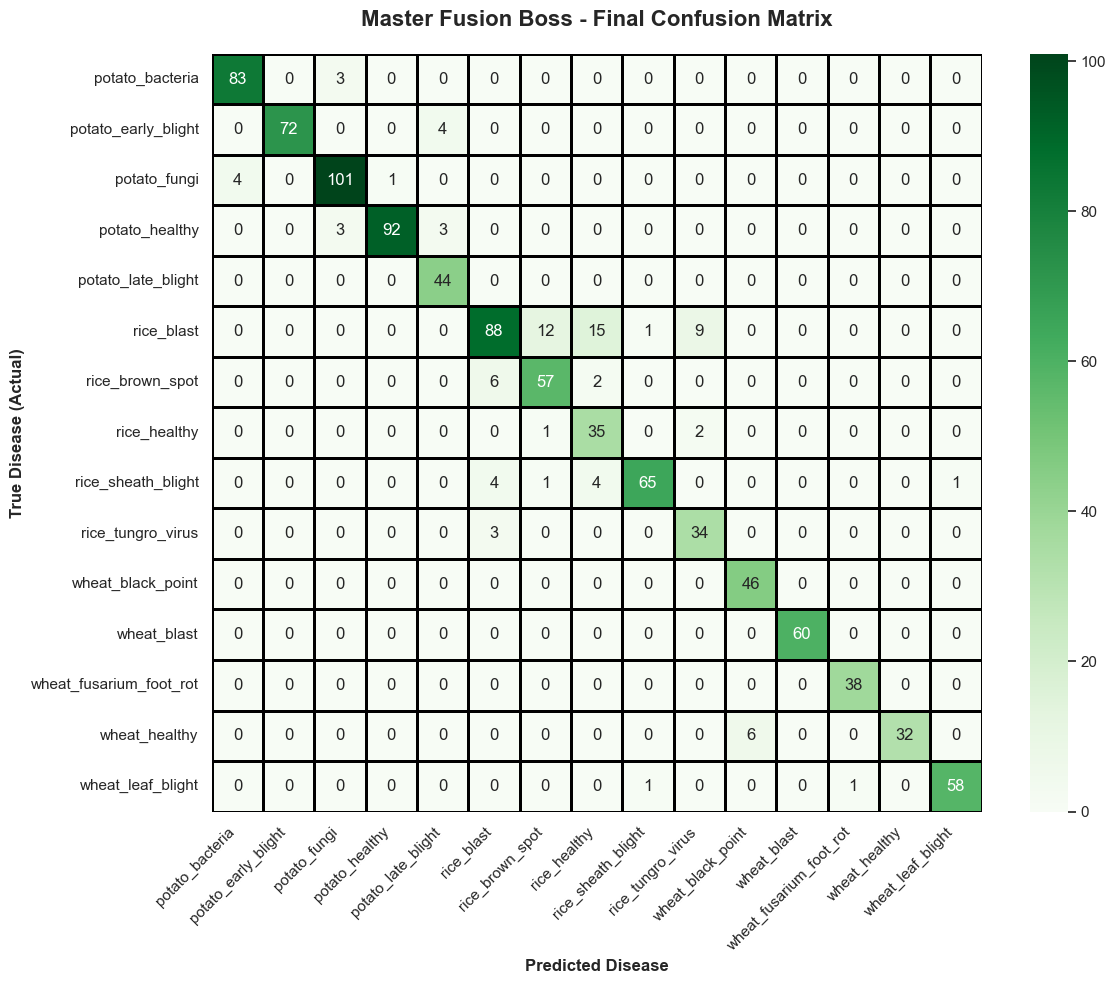

In [1]:
# ==========================================
# CELL #10 - EVALUATE MASTER FUSION BOSS
# ==========================================
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import load_model
from sklearn.metrics import classification_report, confusion_matrix

print("🧹 Scrubbing GPU Memory for clean evaluation...")
tf.keras.backend.clear_session()

# Paths
FINAL_DIR = r"D:\Final_Experiment"
MODEL_PATH = os.path.join(FINAL_DIR, "Final_Fusion_Boss.keras")
TEST_DIR = r"D:\MasterDataset\test"

# ---------------------------------------------------------
# 1. LOAD TEST DATA (Raw Pixels - Boss handles rescaling internally)
# ---------------------------------------------------------
print("📁 Loading Unseen Test Data...")
test_datagen = ImageDataGenerator() 
test_gen = test_datagen.flow_from_directory(
    TEST_DIR, 
    target_size=(224, 224), 
    batch_size=8, 
    class_mode='categorical', 
    shuffle=False # CRITICAL: Must be False
)

# ---------------------------------------------------------
# 2. LOAD MODEL & EVALUATE
# ---------------------------------------------------------
print(f"\n🧠 Loading Master Fusion Boss Model from: {MODEL_PATH}")
fusion_model = load_model(MODEL_PATH)

print("\n📊 Running standard evaluation metric...")
loss, accuracy = fusion_model.evaluate(test_gen, verbose=1)
print(f"\n🏆 MASTER FUSION BOSS TEST ACCURACY: {accuracy * 100:.2f}%")

# ---------------------------------------------------------
# 3. GENERATE PREDICTIONS
# ---------------------------------------------------------
print("\n🔍 Generating detailed predictions for Matrix...")
test_gen.reset() 
predictions = fusion_model.predict(test_gen, verbose=1)

y_pred = np.argmax(predictions, axis=1)
y_true = test_gen.classes
class_names = list(test_gen.class_indices.keys())

# ---------------------------------------------------------
# 4. CLASSIFICATION REPORT
# ---------------------------------------------------------
print("\n📄 --- THESIS DOCUMENTATION: MASTER FUSION BOSS ---")
print(classification_report(y_true, y_pred, target_names=class_names))

# ---------------------------------------------------------
# 5. PLOT CONFUSION MATRIX
# ---------------------------------------------------------
print("\n🎨 Rendering Master Fusion Boss Confusion Matrix...")
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(12, 10))
sns.set_theme(style="whitegrid")

# Using 'Greens' for the final master model
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', 
            xticklabels=class_names, yticklabels=class_names,
            linewidths=1, linecolor='black')

plt.title('Master Fusion Boss - Final Confusion Matrix', fontsize=16, fontweight='bold', pad=20)
plt.ylabel('True Disease (Actual)', fontsize=12, fontweight='bold')
plt.xlabel('Predicted Disease', fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

cm_save_path = os.path.join(FINAL_DIR, "Final_Fusion_Boss_Confusion_Matrix.png")
plt.savefig(cm_save_path)
print(f"✅ Confusion Matrix safely saved to {cm_save_path}")
plt.show()

🧹 Scrubbing GPU Memory for clean evaluation...
📁 Loading Unseen Test Data...
Found 992 images belonging to 15 classes.

🧠 Loading The Ultimate Crop App from: D:\Final_Experiment\The_Ultimate_Crop_App

🔍 Generating predictions batch-by-batch (Bypassing Keras)...
Processing batch 124/124...
✅ Predictions complete!

🏆 FEATURE-LEVEL FUSION (ULTIMATE APP) TEST ACCURACY: 96.27%

📄 --- THESIS DOCUMENTATION: FEATURE-LEVEL FUSION ---
                         precision    recall  f1-score   support

        potato_bacteria       0.98      0.98      0.98        86
    potato_early_blight       1.00      0.99      0.99        76
           potato_fungi       0.95      0.98      0.96       106
         potato_healthy       1.00      0.96      0.98        98
     potato_late_blight       0.98      1.00      0.99        44
             rice_blast       0.97      0.89      0.93       125
        rice_brown_spot       0.94      0.97      0.95        65
           rice_healthy       0.94      0.89      

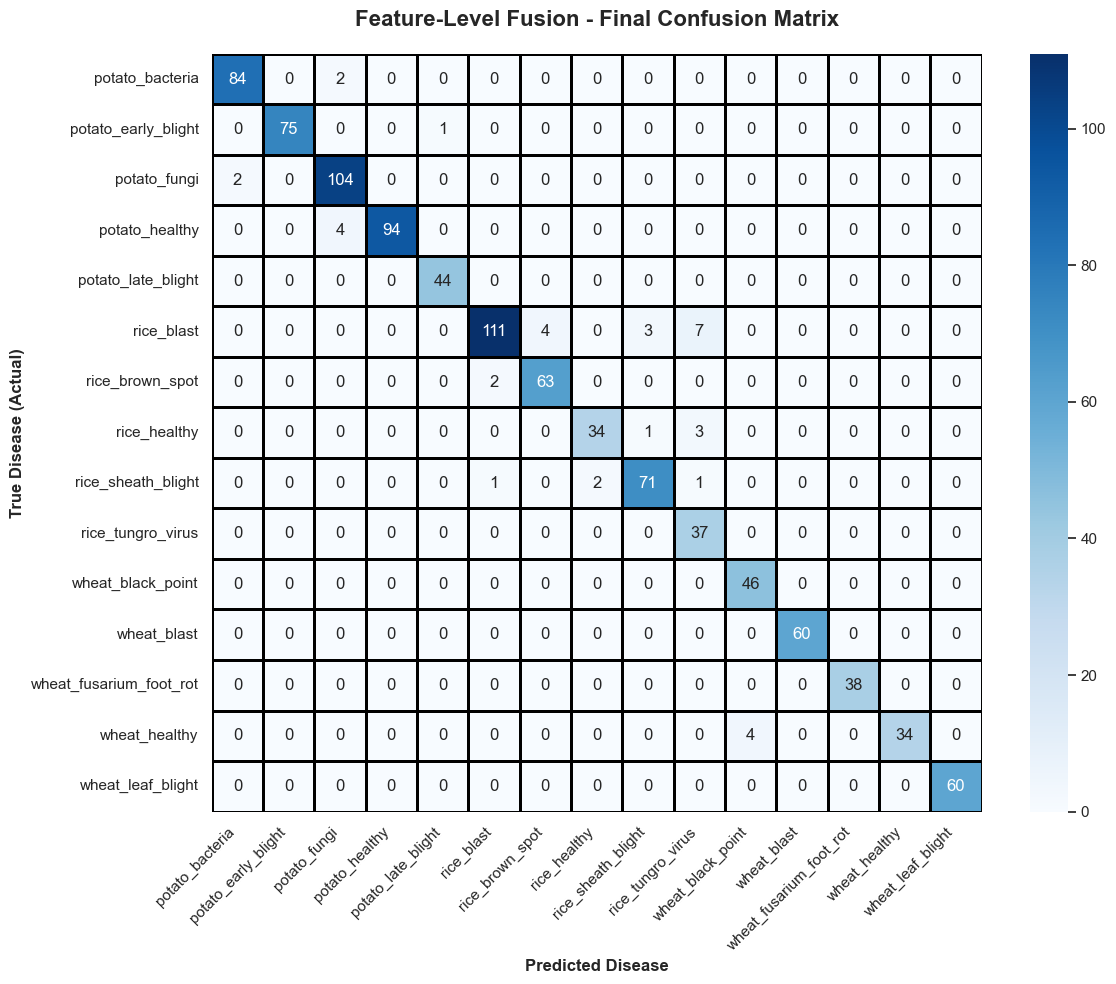

In [3]:
# ==========================================
# CELL #12 - EVALUATE RAW TF SAVEDMODEL (FEATURE-LEVEL FUSION)
# ==========================================
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

print("🧹 Scrubbing GPU Memory for clean evaluation...")
tf.keras.backend.clear_session()

# Paths
FINAL_DIR = r"D:\Final_Experiment"
MODEL_PATH = os.path.join(FINAL_DIR, "The_Ultimate_Crop_App")
TEST_DIR = r"D:\MasterDataset\test"

# ---------------------------------------------------------
# 1. LOAD TEST DATA
# ---------------------------------------------------------
print("📁 Loading Unseen Test Data...")
test_datagen = ImageDataGenerator() 
test_gen = test_datagen.flow_from_directory(
    TEST_DIR, 
    target_size=(224, 224), 
    batch_size=8, 
    class_mode='categorical', 
    shuffle=False # CRITICAL: Must be False
)

# ---------------------------------------------------------
# 2. LOAD RAW TENSORFLOW MODEL
# ---------------------------------------------------------
print(f"\n🧠 Loading The Ultimate Crop App from: {MODEL_PATH}")
# 🚨 THE FIX: Using tf.saved_model.load as required for this format
ultimate_model = tf.saved_model.load(MODEL_PATH)

# ---------------------------------------------------------
# 3. MANUAL PREDICTION LOOP (Replacing .predict and .evaluate)
# ---------------------------------------------------------
print("\n🔍 Generating predictions batch-by-batch (Bypassing Keras)...")
test_gen.reset() 
all_preds = []
all_true = []

steps = len(test_gen)
for i in range(steps):
    x_batch, y_batch = next(test_gen)
    
    # Run the raw TensorFlow prediction graph
    batch_preds = ultimate_model(tf.constant(x_batch))
    
    # Append the results
    all_preds.extend(batch_preds.numpy())
    all_true.extend(np.argmax(y_batch, axis=1))
    
    print(f"Processing batch {i+1}/{steps}...", end='\r')

print("\n✅ Predictions complete!")

y_pred = np.argmax(all_preds, axis=1)
y_true = np.array(all_true)
class_names = list(test_gen.class_indices.keys())

# ---------------------------------------------------------
# 4. CALCULATE ACCURACY & REPORT
# ---------------------------------------------------------
accuracy = accuracy_score(y_true, y_pred)
print(f"\n🏆 FEATURE-LEVEL FUSION (ULTIMATE APP) TEST ACCURACY: {accuracy * 100:.2f}%\n")

print("📄 --- THESIS DOCUMENTATION: FEATURE-LEVEL FUSION ---")
print(classification_report(y_true, y_pred, target_names=class_names))

# ---------------------------------------------------------
# 5. PLOT CONFUSION MATRIX
# ---------------------------------------------------------
print("\n🎨 Rendering Feature-Level Fusion Confusion Matrix...")
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(12, 10))
sns.set_theme(style="whitegrid")

# Using 'Blues' for the Feature-Level Fusion model
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names,
            linewidths=1, linecolor='black')

plt.title('Feature-Level Fusion - Final Confusion Matrix', fontsize=16, fontweight='bold', pad=20)
plt.ylabel('True Disease (Actual)', fontsize=12, fontweight='bold')
plt.xlabel('Predicted Disease', fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

cm_save_path = os.path.join(FINAL_DIR, "Feature_Level_Fusion_Confusion_Matrix.png")
plt.savefig(cm_save_path)
print(f"✅ Confusion Matrix safely saved to {cm_save_path}")
plt.show()